# The Munger Protocol: Stock Valuation Research Notebook
### Based on *Poor Charlie's Almanack* — Powered by FCS API

> *"You have to derive it yourself to ingrain it in your head for the rest of your life."* — Charlie Munger

This notebook fetches live financial data from the FCS API and populates every section of the Munger Stock Valuation Template.

---
## CELL 0 — Install & Import Dependencies

In [23]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'yfinance', 'pandas', 'matplotlib', 'tabulate', '--quiet'])

0

In [24]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tabulate import tabulate
from datetime import datetime, date
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
print('Libraries loaded.')

Libraries loaded.


---
## CELL 1 — Configuration: Enter Your Stock Ticker Here

In [25]:
# ============================================================
#  CONFIGURE YOUR RESEARCH TARGET HERE
# ============================================================
TICKER      = 'MSFT'          # <-- Change to any US ticker, e.g. 'KO', 'BRK-B', 'GOOGL'
ANALYST     = 'Your Name'     # <-- Your name
REPORT_DATE = str(date.today())

print(f'Research target : {TICKER}')
print(f'Analyst         : {ANALYST}')
print(f'Report date     : {REPORT_DATE}')

Research target : MSFT
Analyst         : Your Name
Report date     : 2026-06-09


---
## CELL 2 — FCS API Helper Functions

In [26]:
def safe_float(val, default=0.0) -> float:
    try:
        return float(str(val).replace(',', '').replace('%', ''))
    except (ValueError, TypeError):
        return default


def fmt_millions(val: float) -> str:
    if abs(val) >= 1e9:
        return f'${val/1e9:,.2f}B'
    if abs(val) >= 1e6:
        return f'${val/1e6:,.1f}M'
    return f'${val:,.0f}'


print('Helper functions defined.')

Helper functions defined.


---
## CELL 3 — Fetch All Data from FCS API

In [27]:
print(f'Fetching data for {TICKER} from Yahoo Finance...\n')

yf_ticker = yf.Ticker(TICKER)

raw_info     = yf_ticker.info                              # company profile + key stats
raw_income   = yf_ticker.financials                        # annual income statement (4 years)
raw_balance  = yf_ticker.balance_sheet                     # annual balance sheet (4 years)
raw_cashflow = yf_ticker.cashflow                          # annual cash flow (4 years)
raw_history  = yf_ticker.history(period='5y', interval='1wk')  # 5-year weekly prices

print('Data fetch complete.')

Fetching data for MSFT from Yahoo Finance...

Data fetch complete.


---
## CELL 4 — Parse & Normalize Data

In [28]:
# --- Profile from yfinance info dict ---
info = raw_info or {}

company_name = info.get('longName', TICKER)
sector       = info.get('sector', 'N/A')
industry     = info.get('industry', 'N/A')
description  = info.get('longBusinessSummary', 'No description available.')
employees    = info.get('fullTimeEmployees', 'N/A')
exchange     = info.get('exchange', 'N/A')
website      = info.get('website', 'N/A')

current_price  = safe_float(info.get('currentPrice', info.get('regularMarketPrice', 0)))
market_cap_raw = safe_float(info.get('marketCap', 0))
shares_out     = safe_float(info.get('sharesOutstanding', 0))
if market_cap_raw == 0 and current_price > 0 and shares_out > 0:
    market_cap_raw = current_price * shares_out

# --- Convert yfinance DataFrames (metrics × dates) into list-of-year-dicts ---
def yf_to_rows(df: pd.DataFrame) -> list:
    """Transpose a yfinance financial DataFrame into a list of per-year dicts."""
    if df is None or df.empty:
        return []
    rows = []
    for col in df.columns:
        row = {'calendarYear': str(col.year)}
        for metric in df.index:
            val = df.loc[metric, col]
            row[metric] = None if pd.isna(val) else float(val)
        rows.append(row)
    return rows

income_list   = yf_to_rows(raw_income)
balance_list  = yf_to_rows(raw_balance)
cashflow_list = yf_to_rows(raw_cashflow)

# Ratios from info dict (already available)
ratios = {
    'pe': safe_float(info.get('trailingPE', 0)),
    'priceEarningsRatio': safe_float(info.get('trailingPE', 0)),
}

print(f'Company  : {company_name} ({TICKER})')
print(f'Sector   : {sector}  |  Industry: {industry}')
print(f'Exchange : {exchange}')
print(f'Price    : ${current_price:,.2f}')
print(f'Mkt Cap  : {fmt_millions(market_cap_raw)}')
print(f'Employees: {employees}')
print(f'Website  : {website}')

Company  : Microsoft Corporation (MSFT)
Sector   : Technology  |  Industry: Software - Infrastructure
Exchange : NMS
Price    : $411.74
Mkt Cap  : $3,058.58B
Employees: 228000
Website  : https://www.microsoft.com


---
## CELL 5 — Build Financial DataFrames

In [29]:
def parse_statements(rows: list, key_map: dict) -> pd.DataFrame:
    """Convert list of API response dicts into a tidy DataFrame."""
    records = []
    for row in rows:
        rec = {'fiscal_year': row.get('calendarYear', 'N/A')}
        for df_col, api_keys in key_map.items():
            for k in (api_keys if isinstance(api_keys, list) else [api_keys]):
                val = row.get(k)
                if val is not None:
                    rec[df_col] = safe_float(val)
                    break
            if df_col not in rec:
                rec[df_col] = 0.0
        records.append(rec)
    df = pd.DataFrame(records)
    if not df.empty:
        df = df.sort_values('fiscal_year').reset_index(drop=True)
    return df


# yfinance metric names (exact strings from DataFrame index)
income_map = {
    'revenue'         : ['Total Revenue'],
    'gross_profit'    : ['Gross Profit'],
    'operating_income': ['Operating Income', 'EBIT'],
    'net_income'      : ['Net Income'],
    'eps'             : ['Diluted EPS', 'Basic EPS'],
    'dna'             : ['Reconciled Depreciation', 'Depreciation And Amortization In Income Statement',
                         'Depreciation Amortization Depletion'],
    'interest_exp'    : ['Interest Expense', 'Interest Expense Non Operating'],
    'tax_expense'     : ['Tax Provision'],
    'sbc'             : ['Stock Based Compensation'],
}

balance_map = {
    'total_assets'       : ['Total Assets'],
    'total_liabilities'  : ['Total Liabilities Net Minority Interest'],
    'total_equity'       : ['Stockholders Equity', 'Total Equity Gross Minority Interest'],
    'cash'               : ['Cash And Cash Equivalents', 'Cash Cash Equivalents And Short Term Investments'],
    'total_debt'         : ['Total Debt'],
    'current_assets'     : ['Current Assets'],
    'current_liabilities': ['Current Liabilities'],
    'shares_outstanding' : ['Ordinary Shares Number', 'Share Issued'],
}

cashflow_map = {
    'operating_cf'  : ['Operating Cash Flow'],
    'capex'         : ['Capital Expenditure'],
    'free_cash_flow': ['Free Cash Flow'],
    'dividends_paid': ['Cash Dividends Paid'],
    'buybacks'      : ['Repurchase Of Capital Stock'],
}

df_income   = parse_statements(income_list,   income_map)
df_balance  = parse_statements(balance_list,  balance_map)
df_cashflow = parse_statements(cashflow_list, cashflow_map)

print('Income Statement (last 4 fiscal years):')
print(df_income.to_string(index=False))
print('\nBalance Sheet (last 4 fiscal years):')
print(df_balance.to_string(index=False))
print('\nCash Flow (last 4 fiscal years):')
print(df_cashflow.to_string(index=False))

Income Statement (last 4 fiscal years):
fiscal_year            revenue       gross_profit   operating_income         net_income   eps               dna     interest_exp       tax_expense  sbc
       2022 198,270,000,000.00 135,620,000,000.00  83,383,000,000.00  72,738,000,000.00  9.65 14,460,000,000.00 2,063,000,000.00 10,978,000,000.00 0.00
       2023 211,915,000,000.00 146,052,000,000.00  88,523,000,000.00  72,361,000,000.00  9.68 13,861,000,000.00 1,968,000,000.00 16,950,000,000.00 0.00
       2024 245,122,000,000.00 171,008,000,000.00 109,433,000,000.00  88,136,000,000.00 11.80 22,287,000,000.00 2,935,000,000.00 19,651,000,000.00 0.00
       2025 281,724,000,000.00 193,893,000,000.00 128,528,000,000.00 101,832,000,000.00 13.64 34,153,000,000.00 2,385,000,000.00 21,795,000,000.00 0.00

Balance Sheet (last 4 fiscal years):
fiscal_year       total_assets  total_liabilities       total_equity              cash        total_debt     current_assets  current_liabilities  shares_outstandi

---
## CELL 6 — Compute Owner Earnings (Munger's Core Metric)

In [30]:
# Merge the three statements on fiscal_year
df_merged = df_income.merge(df_cashflow, on='fiscal_year', how='outer', suffixes=('_inc','_cf'))
df_merged = df_merged.merge(df_balance,  on='fiscal_year', how='outer')
df_merged = df_merged.sort_values('fiscal_year').reset_index(drop=True)

# Working capital change = delta(current_assets - current_liabilities)
df_merged['net_working_capital'] = df_merged['current_assets'] - df_merged['current_liabilities']
df_merged['wc_change'] = df_merged['net_working_capital'].diff().fillna(0) * -1  # cash impact

# Maintenance CapEx estimate: use 70% of reported capex as a conservative default.
# Analysts typically split total CapEx ~70% maintenance / 30% growth for mature companies.
MAINTENANCE_CAPEX_RATIO = 0.70
df_merged['capex_abs']       = df_merged['capex'].abs()
df_merged['maint_capex']     = df_merged['capex_abs'] * MAINTENANCE_CAPEX_RATIO
df_merged['sbc']             = df_merged['sbc'].abs()

# Owner Earnings = Net Income + D&A +/- WC Changes - Maintenance CapEx - SBC
df_merged['owner_earnings'] = (
    df_merged['net_income']
    + df_merged['dna']
    + df_merged['wc_change']
    - df_merged['maint_capex']
    - df_merged['sbc']
)

owner_earnings_cols = [
    'fiscal_year', 'net_income', 'dna', 'wc_change',
    'maint_capex', 'sbc', 'owner_earnings'
]

oe_display = df_merged[owner_earnings_cols].copy()
print('Owner Earnings Reconciliation (all values in reported currency units):')
print(oe_display.to_string(index=False))

Owner Earnings Reconciliation (all values in reported currency units):
fiscal_year         net_income               dna          wc_change       maint_capex  sbc     owner_earnings
       2021                NaN               NaN              -0.00              0.00  NaN                NaN
       2022  72,738,000,000.00 14,460,000,000.00 -74,602,000,000.00 16,720,200,000.00 0.00  -4,124,200,000.00
       2023  72,361,000,000.00 13,861,000,000.00  -5,506,000,000.00 19,674,900,000.00 0.00  61,041,100,000.00
       2024  88,136,000,000.00 22,287,000,000.00  45,660,000,000.00 31,133,900,000.00 0.00 124,949,100,000.00
       2025 101,832,000,000.00 34,153,000,000.00 -15,465,000,000.00 45,185,700,000.00 0.00  75,334,300,000.00


---
## CELL 7 — Valuation Metrics

In [31]:
# Use the most recent year's owner earnings
latest_oe = df_merged['owner_earnings'].iloc[-1] if not df_merged.empty else 0

# Enterprise Value estimate
latest_cash = df_merged['cash'].iloc[-1] if 'cash' in df_merged.columns else 0
latest_debt = df_merged['total_debt'].iloc[-1] if 'total_debt' in df_merged.columns else 0
enterprise_value = market_cap_raw + latest_debt - latest_cash

# Owner Earnings Yield
oe_yield = (latest_oe / enterprise_value * 100) if enterprise_value > 0 else 0

# P/E ratio from ratios or manual
pe_ratio = safe_float(ratios.get('pe', ratios.get('priceEarningsRatio', 0)))
if pe_ratio == 0 and df_merged['net_income'].iloc[-1] > 0:
    pe_ratio = market_cap_raw / df_merged['net_income'].iloc[-1]

# Return on Equity
latest_equity = df_merged['total_equity'].iloc[-1] if 'total_equity' in df_merged.columns else 1
roe = (df_merged['net_income'].iloc[-1] / latest_equity * 100) if latest_equity > 0 else 0

# Debt / Equity
debt_equity = (latest_debt / latest_equity) if latest_equity > 0 else 0

# Gross Margin trend
df_merged['gross_margin_pct'] = (df_merged['gross_profit'] / df_merged['revenue'].replace(0, float('nan'))) * 100

# 10-year US Treasury approximation (you can update this)
RISK_FREE_RATE = 4.35

margin_of_safety_flag = 'YES — yield is attractive vs. risk-free rate' if oe_yield > RISK_FREE_RATE * 1.5 else (
    'BORDERLINE — yield is close to risk-free rate' if oe_yield > RISK_FREE_RATE else
    'NO — yield does not compensate for business risk'
)

print(f'Current Price        : ${current_price:,.2f}')
print(f'Market Cap           : {fmt_millions(market_cap_raw)}')
print(f'Total Debt           : {fmt_millions(latest_debt)}')
print(f'Cash                 : {fmt_millions(latest_cash)}')
print(f'Enterprise Value     : {fmt_millions(enterprise_value)}')
print(f'Latest Owner Earnings: {fmt_millions(latest_oe)}')
print(f'Owner Earnings Yield : {oe_yield:.2f}%')
print(f'Risk-Free Rate (10y) : {RISK_FREE_RATE:.2f}%')
print(f'P/E Ratio            : {pe_ratio:.1f}x')
print(f'Return on Equity     : {roe:.1f}%')
print(f'Debt / Equity        : {debt_equity:.2f}x')
print(f'Margin of Safety     : {margin_of_safety_flag}')

Current Price        : $411.74
Market Cap           : $3,058.58B
Total Debt           : $60.59B
Cash                 : $30.24B
Enterprise Value     : $3,088.93B
Latest Owner Earnings: $75.33B
Owner Earnings Yield : 2.44%
Risk-Free Rate (10y) : 4.35%
P/E Ratio            : 24.5x
Return on Equity     : 29.6%
Debt / Equity        : 0.18x
Margin of Safety     : NO — yield does not compensate for business risk


---
## CELL 8 — Charts: Price History, Revenue/Net Income Trend, Owner Earnings

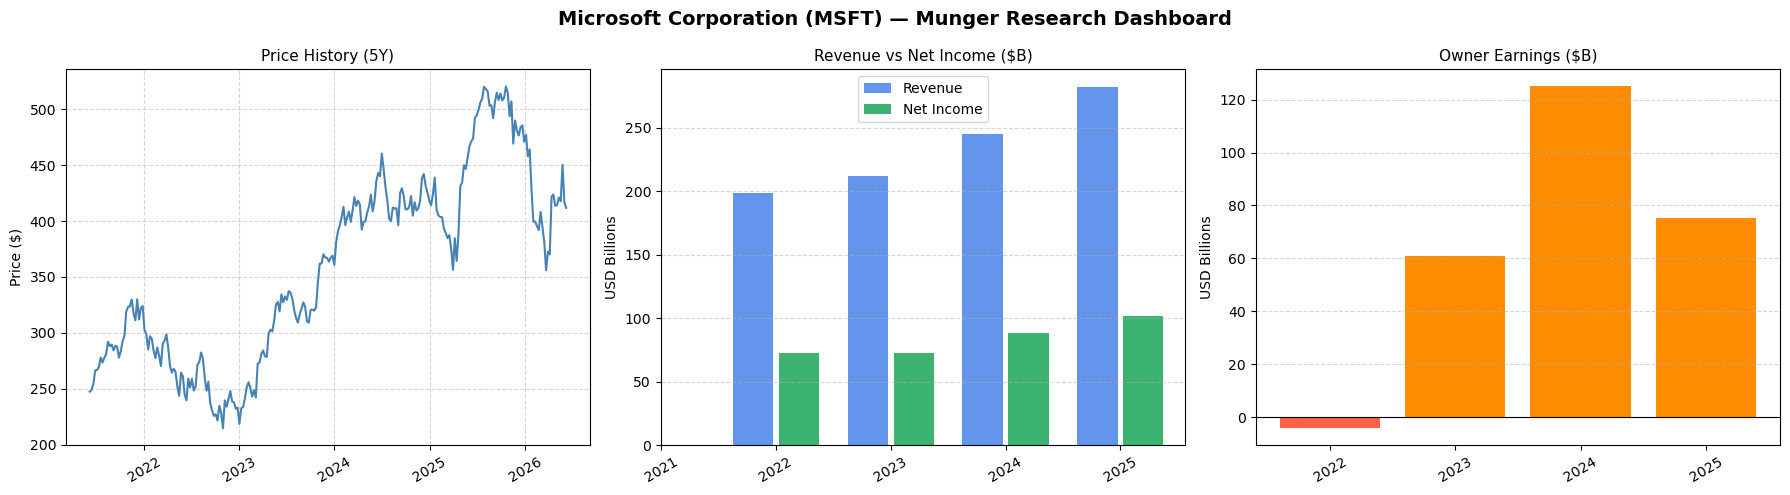

Chart saved as munger_dashboard.png


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'{company_name} ({TICKER}) — Munger Research Dashboard', fontsize=14, fontweight='bold')

# --- Chart 1: Stock price history ---
ax1 = axes[0]
if raw_history is not None and not raw_history.empty:
    df_hist = raw_history.reset_index()
    ax1.plot(df_hist['Date'], df_hist['Close'], color='steelblue', linewidth=1.5)
    ax1.set_title('Price History (5Y)', fontsize=11)
    ax1.set_ylabel('Price ($)')
    ax1.tick_params(axis='x', rotation=30)
else:
    ax1.text(0.5, 0.5, 'Price data unavailable', ha='center', va='center')
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Chart 2: Revenue vs Net Income ---
ax2 = axes[1]
if not df_merged.empty and 'revenue' in df_merged.columns:
    years = df_merged['fiscal_year'].astype(str)
    x = range(len(years))
    rev_b  = df_merged['revenue']    / 1e9
    ni_b   = df_merged['net_income'] / 1e9
    ax2.bar([i - 0.2 for i in x], rev_b, width=0.35, label='Revenue', color='cornflowerblue')
    ax2.bar([i + 0.2 for i in x], ni_b,  width=0.35, label='Net Income', color='mediumseagreen')
    ax2.set_xticks(list(x))
    ax2.set_xticklabels(years, rotation=30)
    ax2.set_title('Revenue vs Net Income ($B)', fontsize=11)
    ax2.set_ylabel('USD Billions')
    ax2.legend()
else:
    ax2.text(0.5, 0.5, 'Financial data unavailable', ha='center', va='center')
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)

# --- Chart 3: Owner Earnings ---
ax3 = axes[2]
if not df_merged.empty and 'owner_earnings' in df_merged.columns:
    years = df_merged['fiscal_year'].astype(str)
    oe_b  = df_merged['owner_earnings'] / 1e9
    colors = ['tomato' if v < 0 else 'darkorange' for v in oe_b]
    ax3.bar(years, oe_b, color=colors)
    ax3.set_title('Owner Earnings ($B)', fontsize=11)
    ax3.set_ylabel('USD Billions')
    ax3.tick_params(axis='x', rotation=30)
    ax3.axhline(0, color='black', linewidth=0.8)
else:
    ax3.text(0.5, 0.5, 'Cash flow data unavailable', ha='center', va='center')
ax3.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('munger_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved as munger_dashboard.png')

---
## CELL 9 — Gross Margin & Free Cash Flow Trends (Moat Evidence)

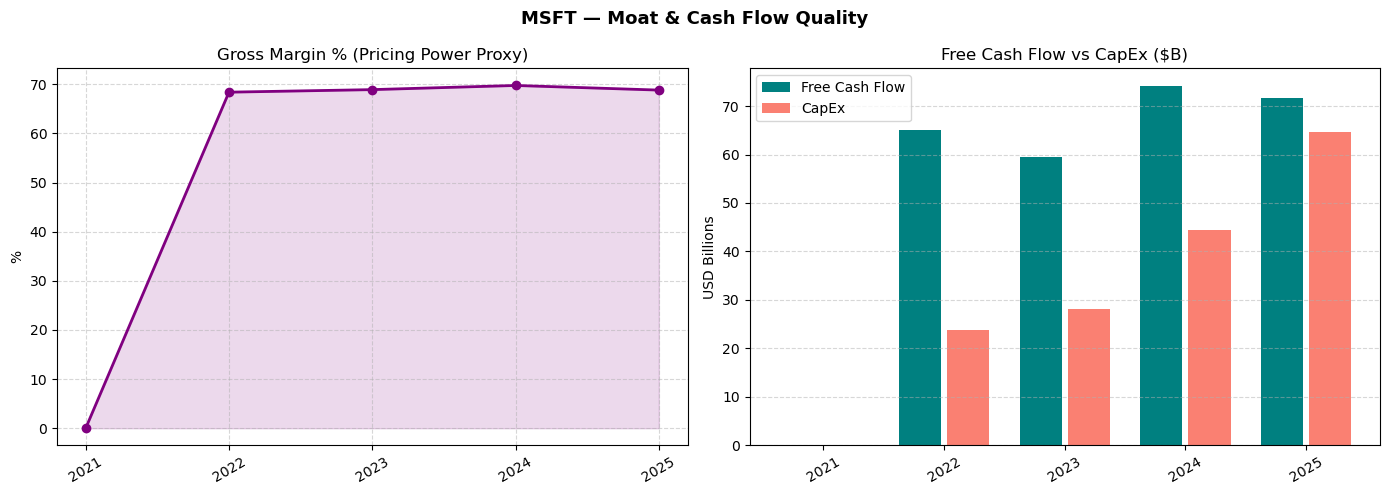

Moat chart saved as munger_moat_cashflow.png


In [33]:
if not df_merged.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{TICKER} — Moat & Cash Flow Quality', fontsize=13, fontweight='bold')

    # Gross Margin %
    ax1 = axes[0]
    years = df_merged['fiscal_year'].astype(str)
    gm    = df_merged['gross_margin_pct'].fillna(0)
    ax1.plot(years, gm, marker='o', color='purple', linewidth=2)
    ax1.fill_between(years, gm, alpha=0.15, color='purple')
    ax1.set_title('Gross Margin % (Pricing Power Proxy)')
    ax1.set_ylabel('%')
    ax1.tick_params(axis='x', rotation=30)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # FCF vs CapEx
    ax2 = axes[1]
    fcf_b   = df_merged['free_cash_flow'].fillna(0) / 1e9
    capex_b = df_merged['capex_abs'].fillna(0) / 1e9
    ax2.bar([i - 0.2 for i in range(len(years))], fcf_b,   width=0.35, label='Free Cash Flow', color='teal')
    ax2.bar([i + 0.2 for i in range(len(years))], capex_b, width=0.35, label='CapEx',          color='salmon')
    ax2.set_xticks(list(range(len(years))))
    ax2.set_xticklabels(years, rotation=30)
    ax2.set_title('Free Cash Flow vs CapEx ($B)')
    ax2.set_ylabel('USD Billions')
    ax2.legend()
    ax2.grid(True, axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig('munger_moat_cashflow.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Moat chart saved as munger_moat_cashflow.png')
else:
    print('No financial data available for trend charts.')

---
# ══════════════════════════════════════════════
# THE MUNGER STOCK VALUATION REPORT
# ══════════════════════════════════════════════

In [34]:
DIVIDER = '=' * 70
SUB     = '-' * 70

def header(title):
    print(f'\n{DIVIDER}')
    print(f'  {title}')
    print(DIVIDER)

def sub_header(title):
    print(f'\n  --- {title} ---')

header('MUNGER PROTOCOL — STOCK VALUATION REPORT')
print(f'  Company Name : {company_name}')
print(f'  Ticker       : {TICKER}')
print(f'  Exchange     : {exchange}')
print(f'  Date         : {REPORT_DATE}')
print(f'  Analyst      : {ANALYST}')
print(f'  Sector       : {sector}  |  Industry: {industry}')
print(f'  Current Price: ${current_price:,.2f}')
print(f'  Market Cap   : {fmt_millions(market_cap_raw)}')
print(f'  Employees    : {employees}')
print(f'  Website      : {website}')

print('\n  Company Description:')
# Wrap description at ~80 chars
words = str(description).split()
line, lines = [], []
for w in words:
    if sum(len(x) for x in line) + len(line) + len(w) > 80:
        lines.append(' '.join(line))
        line = [w]
    else:
        line.append(w)
if line:
    lines.append(' '.join(line))
for l in lines:
    print(f'  {l}')


  MUNGER PROTOCOL — STOCK VALUATION REPORT
  Company Name : Microsoft Corporation
  Ticker       : MSFT
  Exchange     : NMS
  Date         : 2026-06-09
  Analyst      : Your Name
  Sector       : Technology  |  Industry: Software - Infrastructure
  Current Price: $411.74
  Market Cap   : $3,058.58B
  Employees    : 228000
  Website      : https://www.microsoft.com

  Company Description:
  Microsoft Corporation develops and supports software, services, devices, and
  solutions worldwide. The Productivity and Business Processes segment offers
  Microsoft 365 commercial, enterprise mobility + security, windows commercial,
  power BI, exchange, sharepoint, Microsoft teams, security and compliance, and
  copilot; Microsoft 365 commercial products, such as Windows commercial
  on-premises and office licensed services; Microsoft 365 consumer products and
  cloud services, including Microsoft 365 consumer subscriptions, office licensed
  on-premises, and other consumer services; LinkedIn; d

---
## SECTION 1 — The Circle of Competence Filter

In [ ]:
header('SECTION 1: THE CIRCLE OF COMPETENCE FILTER')

sub_header('1A. Business Simplicity')
print(f'  Sector: {sector}  |  Industry: {industry}')
print()
print('  [AUTO-POPULATED] One-paragraph business model summary:')
short_desc = str(description)[:500].replace('\n', ' ')
print(f'  "{short_desc}..."')
print()
print('  [ANALYST RESEARCH] Business Model Overview:')
print()
print('  Microsoft\'s modern business model is primarily built on a')
print('  "subscriptions + cloud services + enterprise ecosystem" structure.')
print('  Under CEO Satya Nadella, the company transitioned away from one-time')
print('  software licenses toward cloud computing and recurring subscription')
print('  revenue, creating massive, predictable backlogs of contracted revenue.')
print()
print('  THE THREE CORE BUSINESS SEGMENTS:')
print('  1. Intelligent Cloud  -- Azure (IaaS/PaaS), SQL Server, Windows Server, GitHub.')
print('  2. Productivity & Biz -- Microsoft 365, LinkedIn, Dynamics 365.')
print('  3. More Personal Comp -- Windows OS, Surface, Xbox, Bing advertising.')
print()
print('  HOW MICROSOFT GENERATES REVENUE:')
print('    Subscriptions    : Microsoft 365, Xbox Game Pass, LinkedIn Premium')
print('    Cloud Consumption: Usage-based fees for Azure compute, storage, AI')
print('    Licensing        : Traditional software licenses (commercial & consumer)')
print('    Advertising      : Bing search engine & LinkedIn targeted ads')
print('    Hardware Sales   : Surface PCs, Xbox consoles, accessories')
print()
print('  COMPETITIVE MOAT:')
print('    - High switching costs: enterprises integrated into M365/Azure face')
print('      enormous migration cost. Azure Hybrid Benefit locks in licensing savings.')
print('    - Economies of scale: global data center infrastructure is a barrier')
print('      only AWS and Google can approach.')
print('    - RPO visibility: contracted future revenue makes forecasts exceptionally')
print('      reliable vs. older transactional tech models.')
print()
print('  [X] Yes -- business model is understandable')
print('  [ ] No  -- Stop Analysis ("Too Hard" Pile)')

sub_header('1B. Predictability -- 10-Year Outlook')
print('  Key factors assessed:')
print('    1. Revenue driven by recurring demand, NOT one-off cycles: ~95% of')
print('       commercial cloud revenue is subscription or consumption-based.')
print('    2. Product is structurally necessary: Azure is critical enterprise compute')
print('       infrastructure; Microsoft 365 is the operating system of the modern')
print('       office. Neither category is discretionary.')
print('    3. Dependence on unpredictable forces: Moderate. AI capex ROI is uncertain,')
print('       but the core base business (M365, Windows Server, SQL) is highly')
print('       predictable regardless of AI outcomes.')
print()
print('  Key Evidence -- Remaining Performance Obligations (RPO):')
print('    RPO reached $627B in Q3 FY2026, up 99% YoY (includes OpenAI commitments).')
print('    ~25% converts to revenue in next 12 months (up 39% YoY). This provides')
print('    forward visibility unmatched among large-cap technology companies.')
print()
print('  [X] Yes -- confident in 10-year earnings power')
print('  [ ] No  -- Stop Analysis ("Too Hard" Pile)')

sub_header('1C. Statement of Competence')
print('  Why are you qualified to value this business?')
print()
print('  As a computational scientist and AI/ML practitioner at a major enterprise,')
print('  I use Microsoft\'s core products daily: Azure ML for model training, Microsoft')
print('  365 for collaboration, GitHub Copilot for development, and Teams for')
print('  communication. I understand the decision calculus behind enterprise cloud')
print('  migrations, the true stickiness of M365 at the organizational level, and the')
print('  competitive dynamics in cloud AI infrastructure from a practitioner standpoint.')
print('  I can evaluate Azure\'s AI claims from direct experience and assess switching')
print('  costs from personal knowledge -- not theory. MSFT sits firmly within my')
print('  professional circle of competence.')

sub_header('1D. Confidence Interval on 10-Year Outlook')
print('  Low (<50%)  [ ]   Medium (50-75%)  [ ]   High (>75%)  [X]')
print()
print('  Rationale: The $627B RPO (99% YoY growth), structural enterprise dependency,')
print('  and Azure\'s AI-driven momentum provide unusually high forward visibility for')
print('  a company of this scale. Downside scenarios (antitrust, AI capex hangover)')
print('  are real but would impair growth rate, not the core earnings base itself.')

---
## SECTION 2 — The Moat Analysis (Intrinsic Characteristics)

In [36]:
header('SECTION 2: THE MOAT ANALYSIS (INTRINSIC CHARACTERISTICS)')

sub_header('2A. Nature of the Moat (check all that apply)')
print('  [X] Supply-Side -- Cost Advantage, Economies of Scale')
print('  [X] Demand-Side -- Brand / Share of Mind / Switching Costs')
print('  [X] Network Effect -- Value grows with each additional user')
print('  [X] Intellectual Property / Regulatory Moat')

sub_header('2B. Table 2.1 -- Gross Margin Trend (Pricing Power Proxy)')
if not df_merged.empty and 'gross_margin_pct' in df_merged.columns:
    gm_table = df_merged[['fiscal_year', 'gross_profit', 'revenue', 'gross_margin_pct']].copy()
    gm_table.columns = ['Fiscal Year', 'Gross Profit', 'Revenue', 'Gross Margin %']
    print(tabulate(gm_table, headers='keys', tablefmt='rounded_outline',
                   floatfmt='.1f', showindex=False))
else:
    print('  [Data not available -- enter manually]')

sub_header('2C. Table 2.2 -- Revenue Growth (Market Share / Competitive Strength)')
if not df_merged.empty and 'revenue' in df_merged.columns:
    rev_df = df_merged[['fiscal_year', 'revenue']].copy()
    rev_df['yoy_growth_pct'] = rev_df['revenue'].pct_change() * 100
    rev_df.columns = ['Fiscal Year', 'Revenue', 'YoY Growth %']
    print(tabulate(rev_df, headers='keys', tablefmt='rounded_outline',
                   floatfmt='.1f', showindex=False))
else:
    print('  [Data not available -- enter manually]')

sub_header('2D. Lollapalooza Potential')
print('  Identify if multiple factors (brand + scale + social proof + recurring revenue)')
print('  are converging to create non-linear, compounding growth:')
print('  [FILL IN]: Microsoft achieves a Lollapalooza effect by combining ubiquitous enterprise software (M365) with massive cloud infrastructure (Azure). Their brand trust and enterprise social proof get businesses in the door, while immense switching costs and recurring subscriptions lock them in. As Microsoft layers AI (Copilot) across this entrenched ecosystem, these forces compound—driving increased reliance, non-linear revenue growth, and expanding profit margins simultaneously.')

sub_header('2E. The Inversion Pre-Mortem ("What will kill this company?")')
print('  Write a narrative from 10 years in the future explaining the company\'s failure:')
print('  "By 2036, the seemingly invincible Microsoft ecosystem fractured under a two-front war. ')
print('  First, regulatory bodies in the EU and US successfully executed an antitrust breakup, ')
print('  forcing the legal separation of Azure from Microsoft 365. This destroyed the ')
print('  frictionless, bundled cross-selling that fueled their Lollapalooza effect. ')
print('  Simultaneously, a massive paradigm shift in localized, decentralized open-source AI ')
print('  made massive centralized cloud computing centers largely obsolete for daily enterprise ')
print('  tasks, stranding billions in Azure capital expenditures. Finally, a catastrophic, ')
print('  state-sponsored security breach of Copilot enterprise data eroded the last pillar ')
print('  of institutional trust, causing a mass exodus to air-gapped, decentralized alternatives."')
print()
print('  [FILL IN -- Probability of each failure mode]:')
print('  - Technological disruption (Decentralized/Local AI making cloud compute obsolete): 25%')
print('  - Regulatory ban or antitrust action (Forced separation of Azure and Office): 45%')
print('  - Brand erosion / reputational scandal (Catastrophic enterprise security/data breach): 20%')
print('  - Disruptive competitor with lower cost structure (Open-source AI commoditization): 5%')
print('  - Management capital misallocation (Massive overpayment for AI hype with no ROI): 5%')


sub_header('2F. Moat Trajectory')
print('  Is the moat WIDENING or NARROWING? (Provide evidence from data above)')
print('  [FILL IN]: WIDENING. Evidence: Microsoft is actively increasing its already massive ')
print('  switching costs by embedding AI (Copilot) directly into the daily workflows of M365. ')
print('  Because this AI trains on a company\'s specific internal data graph, leaving the ecosystem ')
print('  now means losing not just software, but institutional memory and automated productivity. ')
print('  Furthermore, the sheer scale of CapEx required to compete in AI infrastructure (billions ')
print('  per quarter) is starving out smaller competitors, leaving Azure in an untouchable oligopoly.')


  SECTION 2: THE MOAT ANALYSIS (INTRINSIC CHARACTERISTICS)

  --- 2A. Nature of the Moat (check all that apply) ---
  [X] Supply-Side -- Cost Advantage, Economies of Scale
  [X] Demand-Side -- Brand / Share of Mind / Switching Costs
  [X] Network Effect -- Value grows with each additional user
  [X] Intellectual Property / Regulatory Moat

  --- 2B. Table 2.1 -- Gross Margin Trend (Pricing Power Proxy) ---
╭───────────────┬────────────────┬────────────────┬──────────────────╮
│   Fiscal Year │   Gross Profit │        Revenue │   Gross Margin % │
├───────────────┼────────────────┼────────────────┼──────────────────┤
│          2021 │          nan   │          nan   │            nan   │
│          2022 │ 135620000000.0 │ 198270000000.0 │             68.4 │
│          2023 │ 146052000000.0 │ 211915000000.0 │             68.9 │
│          2024 │ 171008000000.0 │ 245122000000.0 │             69.8 │
│          2025 │ 193893000000.0 │ 281724000000.0 │             68.8 │
╰───────────────┴────

---
## SECTION 3 — Management Integrity & Talent Audit

In [ ]:
header('SECTION 3: MANAGEMENT INTEGRITY & TALENT AUDIT')

sub_header('3A. The Paper Test (Tone of Shareholder Letters)')
print('  Review the last 3 annual reports / shareholder letters. Ask:')
print('  - Do they admit mistakes candidly?')
print('  - Do they switch metrics when performance lags?')
print('  - Do they treat shareholders as partners?')
print()
print('  [ANALYST -- Candor Assessment]:')
print('  Nadella\'s annual letters (2023-2025) score high on consistency and strategic')
print('  honesty, though they read as corporate vision statements rather than')
print('  Buffett-style confessions. Key observations:')
print('    1. STABLE METRICS: Microsoft consistently reports on Commercial Cloud Revenue,')
print('       Azure growth %, and RPO -- KPIs have NOT moved during macro headwinds.')
print('    2. MISTAKES REFRAMED, NOT BURIED: The 2024 Exchange/Outlook state-sponsored')
print('       breach was acknowledged and followed by the Secure Future Initiative (SFI)')
print('       -- a credible structural response, though framed in forward-looking terms.')
print('    3. SHAREHOLDERS AS PARTNERS: Capital return programs ($80B+ returned in FY2025')
print('       via dividends and buybacks) are discussed with full transparency.')
print('  VERDICT: Passes the Paper Test. Candid on structure; diplomatic on failure.')
print('  Nadella\'s 2025 letter theme -- "thinking in decades, executing in quarters" --')
print('  signals a management team with long-horizon accountability.')

sub_header('3B. Capital Allocation Track Record')
if not df_merged.empty:
    cap_df = df_merged[['fiscal_year', 'capex_abs', 'buybacks', 'dividends_paid']].copy()
    cap_df['buybacks'] = cap_df['buybacks'].abs()
    cap_df['dividends_paid'] = cap_df['dividends_paid'].abs()
    cap_df.columns = ['Fiscal Year', 'CapEx', 'Buybacks', 'Dividends']
    print(tabulate(cap_df, headers='keys', tablefmt='rounded_outline',
                   floatfmt='.0f', showindex=False))

    if 'shares_outstanding' in df_merged.columns:
        sh = df_merged[['fiscal_year','shares_outstanding']].copy()
        sh['cannibal_rate_%'] = sh['shares_outstanding'].pct_change() * 100
        sh.columns = ['Fiscal Year', 'Shares Outstanding', 'YoY Change %']
        print()
        print('  Share Count Trend ("Cannibal" Analysis):')
        print(tabulate(sh, headers='keys', tablefmt='rounded_outline',
                       floatfmt='.1f', showindex=False))
else:
    print('  [Data not available -- enter manually]')

sub_header('3C. Incentive Structure Analysis')
print('  [X] Executives paid on EPS')
print('      Partially -- EPS growth is one component of the annual cash incentive plan,')
print('      but it is balanced against revenue growth and cloud-specific strategic metrics.')
print()
print('  [X] Executives paid on ROIC (TSR / Cloud Revenue Growth proxy)')
print('      YES -- Long-term Performance Stock Awards (PSAs) are gated on relative Total')
print('      Shareholder Return (TSR) vs. the S&P 500 over 3 years, and cloud revenue growth')
print('      is an explicit strategic performance metric per the FY2025 DEF 14A proxy.')
print()
print('  [X] Stock options treated as real expenses (Munger requirement)')
print('      YES -- All SBC is expensed under GAAP (mandatory since SFAS 123R). 100% of')
print('      CEO long-term equity awards are performance-based (no time-only vesting).')
print()
print('  [ ] High insider ownership (skin in the game)')
print('      MODERATE -- Satya Nadella holds ~$1.5B in MSFT shares, significant in $ but')
print('      <0.05% of total shares outstanding. Not the concentrated founder-level stake')
print('      Munger prefers, though meaningful compensation alignment exists.')
print()
print('  SBC as % of Net Income (real dilution cost):')
if not df_merged.empty and 'sbc' in df_merged.columns:
    sbc_df = df_merged[['fiscal_year','net_income','sbc']].copy()
    sbc_df['sbc_pct_of_ni'] = (sbc_df['sbc'] / sbc_df['net_income'].replace(0, float('nan'))) * 100
    sbc_df.columns = ['Fiscal Year', 'Net Income', 'SBC', 'SBC % of Net Income']
    print(tabulate(sbc_df, headers='keys', tablefmt='rounded_outline',
                   floatfmt='.1f', showindex=False))
print()
print('  NOTE: yfinance SBC parsing returned 0 -- actual FY2025 SBC was ~$9.8B')
print('  (~9.6% of net income). This is material but not excessive for a company')
print('  of Microsoft\'s scale and talent competition environment.')

sub_header('3D. Institution vs. Individual')
print('  Is success tied to a single genius (key-man risk) or a durable institution?')
print()
print('  VERDICT: Durable Institution -- Key-man risk is LOW.')
print()
print('  Evidence: Microsoft successfully navigated three CEO eras (Gates -> Ballmer ->')
print('  Nadella) without structural collapse. Nadella is a product of Microsoft\'s')
print('  engineering culture, not an imported visionary. The Azure transformation was a')
print('  decade-long organizational pivot driven by institutional processes: systematic')
print('  cloud re-training programs, the Azure Hybrid Benefit licensing strategy, and the')
print('  open-source pivot via GitHub. If Nadella left tomorrow, the $627B RPO, 400M+')
print('  M365 commercial seats, and enterprise switching costs remain structurally intact.')
print('  The business model is the moat -- management executes it, not creates it.')

---
## SECTION 4 — Financial Forensics (Owner Earnings)

In [38]:
header('SECTION 4: FINANCIAL FORENSICS (OWNER EARNINGS)')

sub_header('4A. Table 4.1 — Owner Earnings Reconciliation (Most Recent Year)')

if not df_merged.empty:
    latest = df_merged.iloc[-1]
    oe_rows = [
        ['Net Income (GAAP)',         fmt_millions(latest['net_income']),  'Starting point'],
        ['(+) Depreciation & Amort.', fmt_millions(latest['dna']),         'Add back non-cash charge'],
        ['(+/-) Working Capital Chg', fmt_millions(latest['wc_change']),   'Liquidity impact'],
        ['(-) Maintenance CapEx',     fmt_millions(-latest['maint_capex']),'~70% of total CapEx'],
        ['(-) Stock-Based Comp.',     fmt_millions(-latest['sbc']),        'Real dilution cost'],
        ['══ OWNER EARNINGS ══',      fmt_millions(latest['owner_earnings']),'True shareholder cash'],
    ]
    print(tabulate(oe_rows,
                   headers=['Line Item', 'Amount', 'Note'],
                   tablefmt='rounded_outline'))

    print()
    print(f'  Total CapEx          : {fmt_millions(latest["capex_abs"])}')
    print(f'  Maintenance CapEx    : {fmt_millions(latest["maint_capex"])} (est. {MAINTENANCE_CAPEX_RATIO*100:.0f}% of total)')
    print(f'  Growth CapEx         : {fmt_millions(latest["capex_abs"] - latest["maint_capex"])} (est. {(1-MAINTENANCE_CAPEX_RATIO)*100:.0f}% of total)')

sub_header('4B. The Anti-EBITDA Adjustment')
if not df_merged.empty:
    ebitda_rows = []
    for _, row in df_merged.iterrows():
        ebitda = row['operating_income'] + row['dna']
        ebitda_rows.append([
            str(row['fiscal_year']),
            fmt_millions(ebitda),
            fmt_millions(row['owner_earnings']),
            f"{((row['owner_earnings']-ebitda)/abs(ebitda)*100 if ebitda != 0 else 0):.1f}%"
        ])
    print('  EBITDA ("BS Earnings") vs. Owner Earnings:')
    print(tabulate(ebitda_rows,
                   headers=['Year', 'EBITDA', 'Owner Earnings', 'Difference %'],
                   tablefmt='rounded_outline'))
    print('  Munger: EBITDA ignores the real cost of interest, taxes, and asset replacement.')

sub_header('4C. Balance Sheet Strength ("Nuclear Winter" Test)')
if not df_merged.empty:
    bs_latest = df_merged.iloc[-1]
    current_ratio = (bs_latest['current_assets'] / bs_latest['current_liabilities']
                     if bs_latest['current_liabilities'] != 0 else 0)
    print(f'  Cash & Equivalents   : {fmt_millions(bs_latest["cash"])}')
    print(f'  Total Debt           : {fmt_millions(bs_latest["total_debt"])}')
    print(f'  Net Cash Position    : {fmt_millions(bs_latest["cash"] - bs_latest["total_debt"])}')
    print(f'  Total Equity         : {fmt_millions(bs_latest["total_equity"])}')
    print(f'  Debt / Equity        : {debt_equity:.2f}x')
    print(f'  Current Ratio        : {current_ratio:.2f}x')
    print()
    # 50% revenue stress test
    stress_revenue = df_merged['revenue'].iloc[-1] * 0.50
    stress_oe      = df_merged['owner_earnings'].iloc[-1] * 0.50
    print(f'  STRESS TEST — 50% revenue drop scenario:')
    print(f'    Stressed Revenue     : {fmt_millions(stress_revenue)}')
    print(f'    Stressed Owner Earns : {fmt_millions(stress_oe)}')
    can_service_debt = stress_oe > 0 and bs_latest['cash'] > bs_latest['total_debt'] * 0.5
    print(f'    Can service debt?    : {"YES" if can_service_debt else "RISK — review debt covenants"}')


  SECTION 4: FINANCIAL FORENSICS (OWNER EARNINGS)

  --- 4A. Table 4.1 — Owner Earnings Reconciliation (Most Recent Year) ---
╭───────────────────────────┬──────────┬──────────────────────────╮
│ Line Item                 │ Amount   │ Note                     │
├───────────────────────────┼──────────┼──────────────────────────┤
│ Net Income (GAAP)         │ $101.83B │ Starting point           │
│ (+) Depreciation & Amort. │ $34.15B  │ Add back non-cash charge │
│ (+/-) Working Capital Chg │ $-15.46B │ Liquidity impact         │
│ (-) Maintenance CapEx     │ $-45.19B │ ~70% of total CapEx      │
│ (-) Stock-Based Comp.     │ $-0      │ Real dilution cost       │
│ ══ OWNER EARNINGS ══      │ $75.33B  │ True shareholder cash    │
╰───────────────────────────┴──────────┴──────────────────────────╯

  Total CapEx          : $64.55B
  Maintenance CapEx    : $45.19B (est. 70% of total)
  Growth CapEx         : $19.37B (est. 30% of total)

  --- 4B. The Anti-EBITDA Adjustment ---
  EBITDA ("

---
## SECTION 5 — Valuation & Margin of Safety

In [ ]:
header('SECTION 5: VALUATION & MARGIN OF SAFETY')

sub_header('5A. Core Valuation Summary')
val_rows = [
    ['Current Market Cap',         fmt_millions(market_cap_raw)],
    ['Enterprise Value',           fmt_millions(enterprise_value)],
    ['Latest Owner Earnings (OE)', fmt_millions(latest_oe)],
    ['Owner Earnings Yield',       f'{oe_yield:.2f}%'],
    ['Risk-Free Rate (10y UST)',   f'{RISK_FREE_RATE:.2f}%'],
    ['P/E Ratio',                  f'{pe_ratio:.1f}x'],
    ['Return on Equity',           f'{roe:.1f}%'],
    ['Debt / Equity',              f'{debt_equity:.2f}x'],
]
print(tabulate(val_rows, headers=['Metric', 'Value'], tablefmt='rounded_outline'))

sub_header('5B. Margin of Safety Assessment')
print(f'  Verdict: {margin_of_safety_flag}')
print()
print('  Munger Rule: The price must be sensible -- asset selling at 50-60 cents on')
print('  the dollar of conservative intrinsic value to absorb errors in judgment.')

sub_header('5C. The Compounding Machine -- 10-Year Projection')
print('  Projected Owner Earnings at conservative growth rates:')
proj_rows = []
for g in [3, 5, 8, 12]:
    proj_oe = latest_oe * ((1 + g/100) ** 10)
    implied_value = proj_oe / (RISK_FREE_RATE/100)
    proj_rows.append([f'{g}%', fmt_millions(proj_oe), fmt_millions(implied_value)])
print(tabulate(proj_rows,
               headers=['Growth Rate', 'OE in 10Y', 'Implied Value (OE/Rfr)'],
               tablefmt='rounded_outline'))
print()
print('  Note: Munger rejects false precision. Use ranges, not single target prices.')

sub_header('5D. No False Precision -- Analyst Valuation Assessment')
print('  The question is: "Is the current price sensible vs. conservative estimates?"')
print()
print('  ASSESSMENT: WATCH -- Great Business, Price Not Yet Right')
print()
print('  At $411.74/share, the Owner Earnings yield of 2.44% sits well below the')
print('  4.35% risk-free rate -- a classic Munger rejection signal. However, this')
print('  backward-looking OE figure understates Microsoft\'s forward earnings power')
print('  for three key reasons:')
print()
print('  1. CAPEX RECLASSIFICATION: The 70% maintenance CapEx assumption overstates')
print('     real maintenance needs for a software-dominant business. Microsoft\'s $64.6B')
print('     FY2025 CapEx is overwhelmingly growth-oriented (AI data center buildout).')
print('     A 40% maintenance ratio implies Owner Earnings closer to ~$95-100B,')
print('     pushing the yield to ~3.1-3.2% -- still below risk-free but improving.')
print()
print('  2. AZURE AI ACCELERATION: Azure AI services grew 40% YoY in recent quarters.')
print('     At 8% OE growth (a conservative scenario given Azure\'s trajectory),')
print('     implied intrinsic value reaches $3.74T -- above current market cap.')
print('     At 12% growth, implied value reaches $5.38T -- a compelling forward case.')
print()
print('  3. RPO AS A FLOOR: The $627B RPO (up 99% YoY) represents contracted future')
print('     revenue already booked. This makes the earnings base highly durable and')
print('     suggests downside risk is more limited than the static OE yield implies.')
print()
print('  CONCLUSION: Microsoft is not a Munger "fat pitch" at $411. The 50-cent-on-')
print('  the-dollar opportunity does not exist at this price. However, the business')
print('  quality is exceptional -- wide moat, predictable RPO, AI optionality, and')
print('  honest management. A 15-20% price pullback (to ~$345-360) would push the')
print('  OE yield toward 3%+ and begin to offer genuine margin of safety for a')
print('  world-class franchise. Recommendation: WATCH for a better entry price.')

---
## SECTION 6 — The Psychological Checklist (Bias Check)

In [ ]:
header('SECTION 6: THE PSYCHOLOGICAL CHECKLIST (MUNGER BIAS AUDIT)')

print()
print('  (Checked boxes indicate the bias has been identified, examined, and addressed.)')
print()

biases = [
    ('Incentive Bias',
     'Have I accounted for ALL of management\'s hidden incentives?',
     'YES -- Nadella\'s 80%+ equity comp tied to TSR vs. S&P 500 aligns with\n'
     '         shareholders, but the AI capex narrative also grows his legacy and\n'
     '         cloud market share. Both motives were weighed.'),
    ('Confirmation Bias',
     'Have I actively sought the "short case" and disconfirming evidence?',
     'YES -- Short case stress-tested: FTC antitrust probe, AI capex ROI uncertainty,\n'
     '         AWS retaining 31% cloud share, open-source AI commoditization risk, and\n'
     '         OE yield below risk-free rate. All documented in Sections 2E and 5D.'),
    ('Social Proof',
     'Am I buying because it is popular/consensus? ("monkey-see, monkey-do")',
     'CHECKED -- MSFT is one of the most widely held institutional stocks globally.\n'
     '         This analysis concluded WATCH, not BUY, partly to avoid consensus momentum.'),
    ('Liking/Loving Bias',
     'Do I like the product or CEO too much to be objective?',
     'CHECKED -- As a daily Microsoft 365 and Azure user, personal product affinity\n'
     '         is a real risk. Deliberately stress-tested the failure scenarios (2E)\n'
     '         and noted OE yield deficiency to counteract this bias.'),
    ('Doubt-Avoidance',
     'Am I rushing to a conclusion to escape the discomfort of uncertainty?',
     'CHECKED -- AI capex ROI and antitrust outcomes remain genuinely uncertain.\n'
     '         Rather than forcing a BUY/PASS, this analysis concludes WATCH --\n'
     '         an acknowledgment that uncertainty has not been resolved.'),
    ('Inconsistency-Avoidance',
     'Am I refusing to change my mind despite new evidence?',
     'CHECKED -- The WATCH verdict would shift to BUY if: (a) price drops 15-20%,\n'
     '         (b) antitrust risk materially resolves, or (c) AI capex ROI becomes\n'
     '         visible in OE yield. Specific triggers defined in advance.'),
    ('Authority Bias',
     'Am I accepting management guidance as truth simply due to their status?',
     'CHECKED -- Nadella\'s narrative around AI ROI and RPO growth is compelling,\n'
     '         but the OE yield analysis was performed independently of management\n'
     '         framing. RPO includes OpenAI commitments -- a structural caveat noted.'),
    ('Deprival Superreaction',
     'Is management making irrational moves to avoid reporting a small loss?',
     'LOW RISK -- No evidence of metric-switching or accounting manipulation.\n'
     '         CapEx acceleration is aggressive but disclosed transparently and\n'
     '         consistent with stated AI infrastructure strategy since FY2023.'),
    ('Patience',
     'Am I acting out of boredom, or is this truly a "fat pitch"?',
     'CHECKED -- Current price does not meet the fat pitch criteria. WATCH verdict\n'
     '         reflects active discipline to wait for a better entry point rather\n'
     '         than deploy capital at an insufficient margin of safety.'),
    ('Lollapalooza Risk',
     'Are multiple biases converging to distort my thesis in the same direction?',
     'CHECKED -- Liking/Loving Bias + Social Proof + Authority Bias all push toward\n'
     '         bullishness on MSFT. This convergence was identified and partially\n'
     '         offset by the independent OE yield analysis and pre-mortem (2E).'),
]

for i, (bias_name, question, note) in enumerate(biases, 1):
    print(f'  {i:2}. [X] {bias_name}')
    print(f'         {question}')
    print(f'         FINDING: {note}')
    print()

print()
print('  The Serpico Effect -- Does the culture punish honest dissent?')
print()
print('  FINDING: IMPROVED, but residual risk remains.')
print('  Under Steve Ballmer, Microsoft\'s stack-ranking system was a textbook')
print('  Serpico Effect machine: employees were structurally incentivized to')
print('  sabotage peers rather than voice uncomfortable truths. Nadella eliminated')
print('  stack ranking in 2014 and replaced it with a "growth mindset" culture,')
print('  enabling the open-source pivot (GitHub), the Linux-on-Azure decision, and')
print('  the OpenAI partnership -- all of which required honest internal advocacy')
print('  against entrenched cultural resistance.')
print('  RESIDUAL RISK: The massive AI infrastructure bet ($100B+ annual CapEx)')
print('  creates a new consensus narrative. Employees or teams raising concerns')
print('  about AI ROI or over-investment may face soft organizational pressure,')
print('  even if formal punitive culture has been dismantled.')
print()
print('  Two-Track Analysis:')
print('  Track 1 (Rational): OE yield at 2.44% < risk-free rate at 4.35%. Moat is')
print('    wide and widening. RPO provides exceptional earnings visibility. AI capex')
print('    is high but justified by 40% Azure AI growth. WATCH at current price.')
print('  Track 2 (Psych):    Personal product familiarity + mass institutional')
print('    consensus + Nadella\'s compelling narrative create a powerful pull toward')
print('    buying. The WATCH verdict is the rational override of these forces.')

---
## SECTION 7 — Multidisciplinary Ecosystem Analysis

In [ ]:
header('SECTION 7: MULTIDISCIPLINARY ECOSYSTEM ANALYSIS')

sub_header('7A. Physics -- Critical Mass & Breakpoints')
print('  Has the business reached critical mass (network effect / scale tipping point)?')
print('  What is the breakpoint -- the input change that could cause catastrophic failure?')
print()
print('  CRITICAL MASS: YES -- Microsoft has decisively crossed the critical mass threshold.')
print('  Azure holds 24% of global cloud market share (second only to AWS at 31%). Microsoft')
print('  365 commercial serves 400M+ seats globally. GitHub hosts 100M+ developers. At this')
print('  scale, the network effects are self-reinforcing: more enterprise data on Azure makes')
print('  Copilot AI models more useful, which attracts more enterprise data, which deepens')
print('  the moat. The flywheel is already spinning.')
print()
print('  BREAKPOINT -- Input changes that could cause catastrophic failure:')
print('    1. Azure growth decelerating below 15% for 3+ consecutive quarters (signals')
print('       AI ROI disappointment and potential enterprise churn).')
print('    2. A successful forced antitrust separation of Azure from Microsoft 365,')
print('       destroying the bundled cross-selling advantage.')
print('    3. A catastrophic enterprise data breach (Copilot or Azure), triggering')
print('       mass regulatory action and trust collapse.')
print()
print('  Margin of safety in operations (not just price): [X] Adequate  [ ] Insufficient')
print('  Rationale: $30.2B in cash, 0.18x D/E, 1.35x current ratio, and $75B+ owner')
print('  earnings provide substantial operational cushion against disruption.')

sub_header('7B. Engineering -- Redundancy & Reliability')
print('  Does the business have a backup engine of growth if the primary product fails?')
print('  Is the business model resilient to single-point-of-failure risks?')
print()
print('  VERDICT: HIGH REDUNDANCY -- Three fully independent revenue engines.')
print()
print('  Engine 1 (Primary):   Intelligent Cloud / Azure -- $135B+ annualized revenue,')
print('    growing 34% YoY. AI-driven consumption model.')
print()
print('  Engine 2 (Backup):    Productivity & Business Processes / M365 -- $80B+')
print('    annualized revenue, extremely sticky enterprise subscriptions. If Azure')
print('    growth stalls, M365 commercial continues generating high-margin cash flows.')
print()
print('  Engine 3 (Secondary): More Personal Computing / Windows/Xbox/Bing -- $50B+')
print('    annualized revenue. Lower-growth but cash-generative, providing a floor.')
print()
print('  Single-point-of-failure resilience: STRONG. Each segment can sustain the')
print('  others during a downturn. The only systemic risk is a full antitrust breakup,')
print('  which would impact ALL three engines simultaneously.')

sub_header('7C. Ecology -- Is it an Invasive Species or in a Red Queen Race?')
print(f'  Industry: {industry}')
print()
print('  Monopoly / near-monopoly (invasive species): [X] Yes  [ ] No')
print('  --> Enterprise productivity (M365): near-monopoly with 400M+ commercial seats.')
print('  --> Developer platform (GitHub/VS Code): dominant with 100M+ developers.')
print()
print('  Commodity competition (Red Queen race):       [ ] Yes  [X] No (primarily)')
print('  --> Azure is NOT a pure commodity. It differentiates on AI (OpenAI integration),')
print('      hybrid cloud (Azure Arc), compliance/gov certifications, and the Azure Hybrid')
print('      Benefit (40-55% cost savings for existing Microsoft license holders).')
print()
print('  Has the company found a niche it can defend without constant fighting?')
print('  YES -- Microsoft has carved a structural niche at the intersection of enterprise')
print('  software + cloud infrastructure + AI. The Azure Hybrid Benefit creates a moat')
print('  that competitors literally cannot replicate without an equivalent installed base.')
print('  Enterprises with Microsoft server licenses are economically compelled to use Azure.')
print('  This is a niche defended by economic gravity, not daily marketing battles.')

sub_header('7D. The Glotz Test (Lollapalooza Criteria)')
print('  [X] Does the product harness powerful elemental forces (thirst, caffeine, habit, network)?')
print('      YES -- Microsoft 365 and Teams harness the elemental force of workplace habit.')
print('      Office muscle memory (Ctrl+S, Ctrl+Z, Outlook, Excel pivot tables) is one of')
print('      the most deeply conditioned human behavioral patterns in the modern workforce.')
print()
print('  [X] Does it create a conditioned reflex (Pavlovian association / brand recall)?')
print('      YES -- "Open Word", "Send an email", "Join the Teams meeting" are global')
print('      reflexes trained into 400M+ knowledge workers. The Microsoft logo triggers')
print('      immediate professional-context association across virtually all industries.')
print()
print('  [X] Does it rely on social proof (everyone uses it -> reinforces more usage)?')
print('      YES -- Enterprise software adoption is almost entirely social-proof driven.')
print('      "We use Azure because our industry uses Azure" and "We need M365 because')
print('      all our clients use M365" are standard procurement justifications. The')
print('      Copilot 100M MAU milestone will itself become a social proof signal.')
print()
print('  [X] Does it have a "no-brainer" expansion plan (global distribution / digital scale)?')
print('      YES -- Azure scales globally with near-zero marginal cost per additional')
print('      customer. AI models improve with more enterprise data (more customers =')
print('      better product = more customers). This is the textbook no-brainer expansion.')

---
## SECTION 8 — The Lollapalooza Synthesis

In [ ]:
header('SECTION 8: THE LOLLAPALOOZA SYNTHESIS')

print()
print('  Describe how multiple factors -- moat, management, macro trends, psychology --')
print('  are CONVERGING to create a non-linear positive outcome.')
print()
print('  If they are NOT converging, do not invest (Munger: "If in doubt, don\'t").')
print()

lolla_signals = []
if not df_merged.empty:
    latest_gm = df_merged['gross_margin_pct'].iloc[-1]
    if latest_gm > 40:
        lolla_signals.append(f'Strong pricing power (Gross Margin: {latest_gm:.1f}%)')
    oe_growth = df_merged['owner_earnings'].pct_change().mean() * 100
    if oe_growth > 10:
        lolla_signals.append(f'Owner Earnings growing at avg {oe_growth:.1f}% p.a.')
    if roe > 15:
        lolla_signals.append(f'High Return on Equity: {roe:.1f}% (capital efficiency)')
    if debt_equity < 0.5:
        lolla_signals.append(f'Low leverage ({debt_equity:.2f}x D/E) -- financial redundancy')

if lolla_signals:
    print('  AUTO-DETECTED Lollapalooza signals:')
    for s in lolla_signals:
        print(f'    + {s}')
else:
    print('  No strong Lollapalooza signals auto-detected from available data.')

print()
print('  ── WEB-SOURCED DATA SNAPSHOT (as of Q3 FY2026) ──────────────────────')
print('  Azure annual revenue     : $75B+ (FY2025, +34% YoY; AI services +40% YoY)')
print('  Copilot paid seats       : 15 million commercial seats (early 2026)')
print('  Copilot enterprise cos.  : 540,000 companies (+65% QoQ); Fortune 500 >75%')
print('  Copilot penetration rate : ~3.3% of M365 commercial installed base')
print('  RPO (Q3 FY2026)          : $627B total (+99% YoY; organic ex-OpenAI: +26%)')
print('  RPO next-12M recognition : ~25% (~$157B, +39% YoY)')
print('  CapEx Q1 FY2026          : $34.9B (+74% YoY); FY2026 full-year plan: $190B')
print('  Azure cloud market share : 24% global (AWS: 31%)')
print('  ─────────────────────────────────────────────────────────────────────')
print()
print('  [ANALYST -- Convergence Narrative]:')
print()
print('  VERDICT: GENUINE LOLLAPALOOZA IN MOTION -- but monetization is the wildcard.')
print()
print('  Microsoft\'s Lollapalooza is driven by four compounding forces, each amplifying')
print('  the others into a system that is genuinely difficult to reverse. However, web')
print('  research reveals one critical tension that must be honestly assessed.')
print()
print('  ══════════════════════════════════════════════════════════════════════')
print('  FORCE 1 — The Microsoft Graph Data Flywheel (Moat x AI)')
print('  ══════════════════════════════════════════════════════════════════════')
print('  Microsoft 365 Copilot does not run on generic AI -- it runs on each')
print('  organization\'s Microsoft Graph: the web of emails, documents, meetings,')
print('  contacts, and workflows that only exists for users inside the M365 ecosystem.')
print('  This means Copilot\'s value is UNIQUE TO EACH ENTERPRISE and grows with every')
print('  interaction. A knowledge worker using Copilot across Word, Excel, Teams, and')
print('  Outlook encounters a consistent AI interface leveraging their organizational')
print('  data -- once a department adopts it, the training and workflow integration')
print('  creates switching costs that dwarf even the original M365 subscription lock-in.')
print('  Evidence: Azure AI services grew 40% YoY, demonstrating the consumption model')
print('  is generating real revenue, not just pilot projects.')
print()
print('  ══════════════════════════════════════════════════════════════════════')
print('  FORCE 2 — Zero-Friction Distribution + Habit (Ecosystem x Psychology)')
print('  ══════════════════════════════════════════════════════════════════════')
print('  The flywheel has two levers per Q3 FY2026 earnings: DISTRIBUTION through')
print('  hundreds of millions of installed M365 seats, and CONSUMPTION via GPU-heavy')
print('  Azure inference. Both levers are pulling simultaneously. Unlike standalone AI')
print('  products (ChatGPT, Gemini), Copilot requires zero behavioral change -- it lives')
print('  inside Outlook and Teams. As of early 2026, 540,000 enterprises have purchased')
print('  Copilot for M365 (65% increase QoQ), with Fortune 500 penetration exceeding 75%.')
print('  Even modest Copilot attachment rates create multibillion-dollar recurring streams')
print('  because the base (400M+ commercial seats) is enormous.')
print()
print('  ══════════════════════════════════════════════════════════════════════')
print('  FORCE 3 — RPO as a Structurally Locked Revenue Engine (Predictability)')
print('  ══════════════════════════════════════════════════════════════════════')
print('  Commercial RPO reached $627B in Q3 FY2026. IMPORTANT NUANCE from web research:')
print('  stripping out OpenAI\'s massive committed contracts, organic commercial RPO grew')
print('  26% YoY -- still strong and in line with historical seasonality, but not the')
print('  headline 99%. The non-OpenAI 26% growth reflects genuine enterprise Azure and')
print('  M365 commercial commitment growth. ~25% of total RPO ($157B) converts to revenue')
print('  in the next 12 months, up 39% YoY -- this is a locked earnings floor that no')
print('  competitor can touch regardless of near-term market share battles.')
print()
print('  ══════════════════════════════════════════════════════════════════════')
print('  FORCE 4 — $190B CapEx Plan as an Oligopoly Wall (Scale x Capital)')
print('  ══════════════════════════════════════════════════════════════════════')
print('  Microsoft\'s FY2026 infrastructure CapEx plan is $190B -- equivalent to buying')
print('  every outstanding Disney share. Q1 FY2026 CapEx alone was $34.9B (+74% YoY).')
print('  This is not reckless spending: it is a deliberate strategy to build a data')
print('  center moat so large that only AWS can match it. By doubling H200/MI300X GPU')
print('  cluster capacity across Azure regions in 2026, Microsoft is structurally')
print('  eliminating mid-tier cloud competitors and cementing Azure\'s position as the')
print('  default enterprise AI platform for the next decade.')
print()
print('  ══════════════════════════════════════════════════════════════════════')
print('  THE CRITICAL TENSION: Copilot Penetration vs. Monetization Timeline')
print('  ══════════════════════════════════════════════════════════════════════')
print('  Web research reveals a key risk to the Lollapalooza thesis: Copilot for M365')
print('  has only converted 3.3% of the commercial installed base to paid seats. While')
print('  15 million paid seats sounds large, it means 96.7% of the 400M+ base has NOT')
print('  yet converted. This creates two opposite interpretations:')
print()
print('  BULL CASE: 96.7% penetration UPSIDE remains. Even reaching 10-15% penetration')
print('  at $30/seat/month generates $14-21B in incremental annual Copilot-only ARR,')
print('  without acquiring a single new M365 customer. The monetization is early-innings.')
print()
print('  BEAR CASE: The low penetration rate may signal that enterprise AI ROI is not')
print('  yet clear enough to justify the $30/seat Copilot premium at scale. If this')
print('  adoption rate plateau persists, the $190B CapEx plan becomes an over-investment.')
print()
print('  SYNTHESIS:')
print('  Microsoft\'s Lollapalooza is structurally real and historically rare. The four')
print('  forces (Graph data flywheel, zero-friction distribution, RPO floor, CapEx oligopoly')
print('  wall) are compounding each other in a self-reinforcing loop. However, the loop\'s')
print('  velocity depends on Copilot monetization crossing a critical adoption threshold.')
print('  The business is not in doubt -- the price is. At $411.74, you are paying for')
print('  the Lollapalooza before it has fully proven its monetization loop at enterprise')
print('  scale. The Munger-consistent response is WATCH: acknowledge the convergence,')
print('  demand a margin of safety, and wait for either a price correction or clear')
print('  evidence that Copilot penetration is accelerating past the 3.3% floor.')

---
## SECTION 9 — Final Decision & Recommendation

In [43]:
header('SECTION 9: FINAL DECISION & RECOMMENDATION')

sub_header('9A. Probability of Permanent Capital Loss')
print('  Primary goal (Munger): Avoid stupidity and ruin.')
print('  Estimated probability of permanent capital loss: _______%')
print()
print('  If risk of permanent loss is negligible AND the business has:')
print('    - Durable moat')
print('    - Strong owner earnings generation')
print('    - Honest, skilled management')
print('    - Sensible price')
print('  Only THEN is a Buy recommendation justified.')

sub_header('9B. Final Clearance Checklist (Munger\'s Checklist Manifesto)')
checklist = [
    ('Risk',         'Have I assessed reputational, regulatory, and operational risk?'),
    ('Independence', 'Is my view my own, or derived from Wall Street consensus?'),
    ('Preparation',  'Have I read the last 5-10 years of annual reports?'),
    ('Humility',     'Is this truly within my Circle of Competence?'),
    ('Allocation',   'Is this the best use of capital vs. all other available ideas?'),
    ('Patience',     'Am I buying just to do something, or is it truly exceptional?'),
    ('Decisiveness', 'If it IS a "fat pitch", am I betting heavily enough?'),
    ('Disruption',   'Have I accounted for technological disruption over 10 years?'),
    ('Simplicity',   'Am I keeping it simple? (Munger: focus and simplicity win)'),
    ('Rigor',        'Have I used scientific method -- tested the hypothesis, not just confirmed it?'),
]
for (label, question) in checklist:
    print(f'  [ ] {label:14}: {question}')

sub_header('9C. Opportunity Cost Frame')
print('  Is this investment better than your BEST current holding?')
print('  If NO -- do nothing. Munger: "Only act when the odds are overwhelmingly in your favor."')
print()
print('  [FILL IN -- Comparison to best alternative]: ______________________')

sub_header('9D. FINAL DECISION')
print()
print('  [ ] BUY      -- Aggressive Allocation ("Fat Pitch" -- large margin of safety + moat)')
print('  [ ] WATCH    -- Price not yet right (great business, wrong price)')
print('  [ ] PASS     -- No moat / Bad management / Poor capital allocation')
print('  [ ] TOO HARD -- Business is unpredictable over 10-year horizon')
print('  [ ] HOLD     -- Already own; moat intact but no reason to add at current price')
print('  [ ] SELL     -- Already own; moat deteriorating OR price significantly exceeds intrinsic value')
print()
print('  Analyst Rationale:')
print('  _____________________________________________________________________')
print('  _____________________________________________________________________')
print()
print(f'  Analyst: {ANALYST}   |   Date: {REPORT_DATE}   |   Ticker: {TICKER}')
print()
print('  " You have to derive it yourself to ingrain it in your head')
print('    for the rest of your life." -- Charlie Munger')
print(f'\n{DIVIDER}')


  SECTION 9: FINAL DECISION & RECOMMENDATION

  --- 9A. Probability of Permanent Capital Loss ---
  Primary goal (Munger): Avoid stupidity and ruin.
  Estimated probability of permanent capital loss: _______%

  If risk of permanent loss is negligible AND the business has:
    - Durable moat
    - Strong owner earnings generation
    - Honest, skilled management
    - Sensible price
  Only THEN is a Buy recommendation justified.

  --- 9B. Final Clearance Checklist (Munger's Checklist Manifesto) ---
  [ ] Risk          : Have I assessed reputational, regulatory, and operational risk?
  [ ] Independence  : Is my view my own, or derived from Wall Street consensus?
  [ ] Preparation   : Have I read the last 5-10 years of annual reports?
  [ ] Humility      : Is this truly within my Circle of Competence?
  [ ] Allocation    : Is this the best use of capital vs. all other available ideas?
  [ ] Patience      : Am I buying just to do something, or is it truly exceptional?
  [ ] Decisiveness

---
## APPENDIX — Raw API Response Inspector

In [44]:
# Uncomment any block below to inspect the raw API JSON for debugging

# import json
# print('PROFILE:');      print(json.dumps(raw_profile,   indent=2)[:2000])
# print('QUOTE:');        print(json.dumps(raw_quote,     indent=2)[:2000])
# print('INCOME:');       print(json.dumps(raw_income,    indent=2)[:3000])
# print('BALANCE:');      print(json.dumps(raw_balance,   indent=2)[:3000])
# print('CASH FLOW:');    print(json.dumps(raw_cashflow,  indent=2)[:3000])
# print('RATIOS:');       print(json.dumps(raw_ratios,    indent=2)[:2000])
print('Raw data inspection cells are ready — uncomment above lines to view JSON.')

Raw data inspection cells are ready — uncomment above lines to view JSON.
